 DATASET

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# XOR dataset
X = np.array([[0,0],
              [0,1],
              [1,0],
              [1,1]], dtype=float)

y = np.array([[0],
              [1],
              [1],
              [0]], dtype=float)


IMPLEMENTATION OF KERAS

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


Keras Predictions:
[[0]
 [1]
 [1]
 [0]]
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step


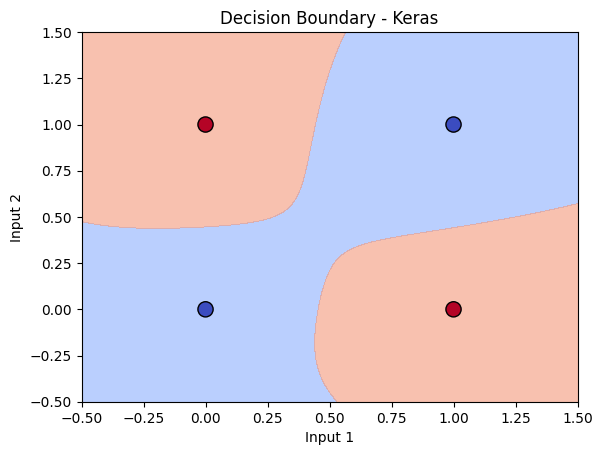

In [16]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Fix randomness
np.random.seed(1)
tf.random.set_seed(1)

# Build model
model_keras = Sequential([
    Dense(4, input_dim=2, activation='tanh'),
    Dense(1, activation='sigmoid')
])

model_keras.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

# Train
model_keras.fit(X, y, epochs=5000, verbose=0)

# Predictions
pred_keras = (model_keras.predict(X) > 0.5).astype(int)
print("Keras Predictions:")
print(pred_keras)

# Decision Boundary
xx, yy = np.meshgrid(np.linspace(-0.5,1.5,300),
                     np.linspace(-0.5,1.5,300))
grid = np.c_[xx.ravel(), yy.ravel()]
Z = model_keras.predict(grid).reshape(xx.shape)

plt.figure()
plt.contourf(xx, yy, Z, levels=[0,0.5,1], cmap='coolwarm', alpha=0.6)
plt.scatter(X[:,0], X[:,1], c=y[:,0], edgecolors='k', s=120, cmap='coolwarm')
plt.title("Decision Boundary - Keras")
plt.xlabel("Input 1")
plt.ylabel("Input 2")
plt.show()


In the Keras implementation, the network was created using a high-level Sequential model and trained using the built-in training function.


IMPLEMENTATION OF PYTORCH

PyTorch Predictions:
[[0]
 [1]
 [1]
 [0]]


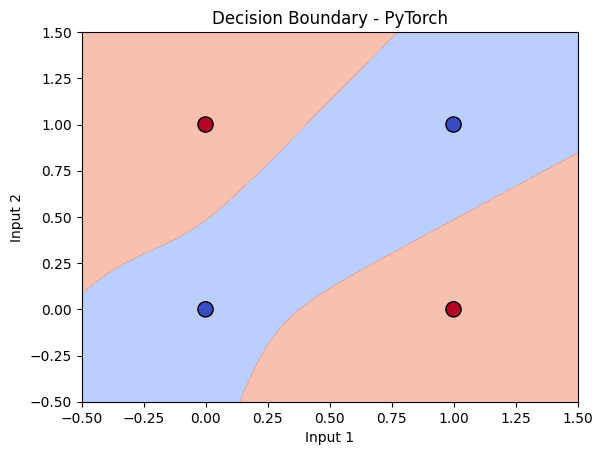

In [17]:
import torch
import torch.nn as nn

# Fix randomness
torch.manual_seed(1)

X_t = torch.tensor(X, dtype=torch.float32)
y_t = torch.tensor(y, dtype=torch.float32)

# Model
model_pt = nn.Sequential(
    nn.Linear(2, 4),
    nn.Tanh(),
    nn.Linear(4, 1),
    nn.Sigmoid()
)

criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model_pt.parameters(), lr=0.01)

# Train
for _ in range(5000):
    optimizer.zero_grad()
    loss = criterion(model_pt(X_t), y_t)
    loss.backward()
    optimizer.step()

# Predictions
pred_pt = (model_pt(X_t) > 0.5).int()
print("PyTorch Predictions:")
print(pred_pt.numpy())

# Decision Boundary
xx, yy = np.meshgrid(np.linspace(-0.5,1.5,300),
                     np.linspace(-0.5,1.5,300))
grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
Z = model_pt(grid).detach().numpy().reshape(xx.shape)

plt.figure()
plt.contourf(xx, yy, Z, levels=[0,0.5,1], cmap='coolwarm', alpha=0.6)
plt.scatter(X[:,0], X[:,1], c=y[:,0], edgecolors='k', s=120, cmap='coolwarm')
plt.title("Decision Boundary - PyTorch")
plt.xlabel("Input 1")
plt.ylabel("Input 2")
plt.show()


In the PyTorch implementation, the network architecture, loss function, and training loop were explicitly defined, providing more control over the learning process.

IMPLEMENTATION OF TENSORFLOW


TensorFlow Predictions:
[[0]
 [1]
 [1]
 [0]]


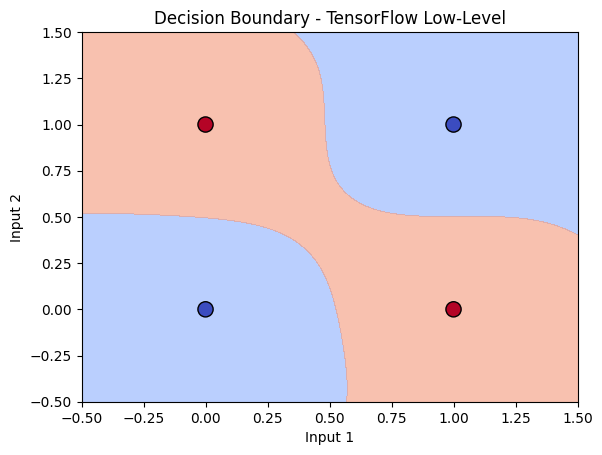

In [19]:
# Fix randomness
np.random.seed(1)
tf.random.set_seed(1)

X_tf = tf.constant(X, dtype=tf.float32)
y_tf = tf.constant(y, dtype=tf.float32)

# Parameters
W1 = tf.Variable(tf.random.normal([2,4], stddev=0.5))
b1 = tf.Variable(tf.zeros([4]))
W2 = tf.Variable(tf.random.normal([4,1], stddev=0.5))
b2 = tf.Variable(tf.zeros([1]))

optimizer = tf.optimizers.Adam(0.01)

# Train
for _ in range(5000):
    with tf.GradientTape() as tape:
        h = tf.tanh(tf.matmul(X_tf, W1) + b1)
        out = tf.sigmoid(tf.matmul(h, W2) + b2)
        loss = tf.reduce_mean(
            tf.keras.losses.binary_crossentropy(y_tf, out)
        )
    grads = tape.gradient(loss, [W1,b1,W2,b2])
    optimizer.apply_gradients(zip(grads, [W1,b1,W2,b2]))

# Predictions
pred_tf = (out > 0.5).numpy().astype(int)
print("TensorFlow Predictions:")
print(pred_tf)

# Decision Boundary
xx, yy = np.meshgrid(np.linspace(-0.5,1.5,300),
                     np.linspace(-0.5,1.5,300))
grid = tf.constant(np.c_[xx.ravel(), yy.ravel()], dtype=tf.float32)

h = tf.tanh(tf.matmul(grid, W1) + b1)
Z = tf.sigmoid(tf.matmul(h, W2) + b2).numpy().reshape(xx.shape)

plt.figure()
plt.contourf(xx, yy, Z, levels=[0,0.5,1], cmap='coolwarm', alpha=0.6)
plt.scatter(X[:,0], X[:,1], c=y[:,0], edgecolors='k', s=120, cmap='coolwarm')
plt.title("Decision Boundary - TensorFlow Low-Level")
plt.xlabel("Input 1")
plt.ylabel("Input 2")
plt.show()


In the TensorFlow low-level implementation, weights, biases, and gradient updates were manually handled using GradientTape.

**CONCLUSION**

The XOR problem was successfully solved using MLPs in Keras, PyTorch, and TensorFlow low-level API, demonstrating that different deep learning frameworks can achieve the same learning objective despite differences in abstraction and implementation.
